# HyDMIS, DeFaktS EDA
## German Social Media Disinformation Domain

**Dataset:** DeFaktS, 105,855 German Twitter posts (Ashraf et al., 2024)
**Key finding:** 81.1% binary label missingness, span labels primary annotation (86.3% coverage)
**Purpose:** HyDMIS German fine-grained span-level disinformation detection

In [1]:
import sys, os, warnings
sys.path.insert(0, '../src')
warnings.filterwarnings('ignore')
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
from defakts_loader import load_defakts

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['font.size'] = 11
os.makedirs('../figures/eda', exist_ok=True)
LABEL_COLORS = {1: '#e74c3c', 0: '#2ecc71', 'unlabeled': '#95a5a6'}
print('Imports complete')

Imports complete


In [2]:
result = load_defakts(data_dir='../data/raw')
df = result['data'].copy()
df['dt'] = pd.to_datetime(df['DateTime'], unit='ms', errors='coerce')
df['year'] = df['dt'].dt.year
df['has_span'] = df['span_labels'].apply(lambda x: len(x) > 0 if isinstance(x, list) else False)
df['span_count'] = df['span_labels'].apply(lambda x: len(x) if isinstance(x, list) else 0)
df['text_len'] = df['text'].astype(str).str.len()
df['text_words'] = df['text'].astype(str).str.split().str.len()
print(f'Shape: {df.shape}')
print(f'Total: {len(df):,} | Binary labeled: {df["binary_label"].notna().sum():,} ({df["binary_label"].notna().mean():.1%})')
print(f'Span labeled: {df["has_span"].sum():,} ({df["has_span"].mean():.1%})')

Loading DeFaktS...


   DeFaktS: 105,855 records | Social Media | German


Shape: (105855, 20)
Total: 105,855 | Binary labeled: 20,008 (18.9%)
Span labeled: 91,403 (86.3%)


## 1. Binary Label Distribution, 81.1% Unlabeled

Only 18.9% binary labeled. Among labeled: dis=41.1%, cred=58.9%.
Span labels are primary annotation, 86.3% coverage.

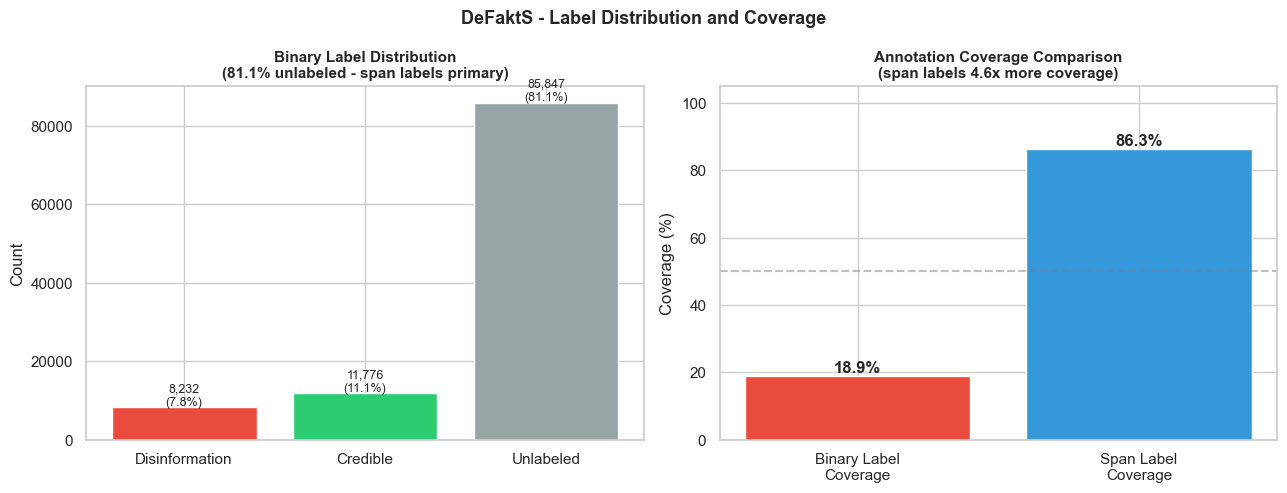

Fig 1 saved, defakts_label_distribution.png


In [3]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Overall label status
total = len(df)
dis = (df['binary_label']==1).sum()
cred = (df['binary_label']==0).sum()
unlabeled = df['binary_label'].isna().sum()
bars = axes[0].bar(['Disinformation', 'Credible', 'Unlabeled'],
                   [dis, cred, unlabeled],
                   color=['#e74c3c','#2ecc71','#95a5a6'], edgecolor='white')
for bar, val in zip(bars, [dis, cred, unlabeled]):
    axes[0].text(bar.get_x()+bar.get_width()/2, bar.get_height()+500,
                 f'{val:,}\n({val/total:.1%})', ha='center', fontsize=9)
axes[0].set_title('Binary Label Distribution\n(81.1% unlabeled - span labels primary)', fontsize=11, fontweight='bold')
axes[0].set_ylabel('Count')

# Annotation coverage comparison
axes[1].bar(['Binary Label\nCoverage', 'Span Label\nCoverage'],
            [df['binary_label'].notna().mean()*100, df['has_span'].mean()*100],
            color=['#e74c3c','#3498db'], edgecolor='white')
axes[1].axhline(50, color='gray', linestyle='--', alpha=0.5)
for i, val in enumerate([df['binary_label'].notna().mean()*100, df['has_span'].mean()*100]):
    axes[1].text(i, val+1, f'{val:.1f}%', ha='center', fontsize=12, fontweight='bold')
axes[1].set_title('Annotation Coverage Comparison\n(span labels 4.6x more coverage)', fontsize=11, fontweight='bold')
axes[1].set_ylabel('Coverage (%)'); axes[1].set_ylim(0, 105)

plt.suptitle('DeFaktS - Label Distribution and Coverage', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../figures/eda/defakts_label_distribution.png', dpi=150, bbox_inches='tight')
plt.show(); print('Fig 1 saved, defakts_label_distribution.png')

## 2. Span Label Types, corpkeyword Dominates (72.8%)

168,270 total span annotations. corpkeyword=72.8%, catneutral=11.7%, catposfake=1.9%.
catposfake is primary disinformation signal.

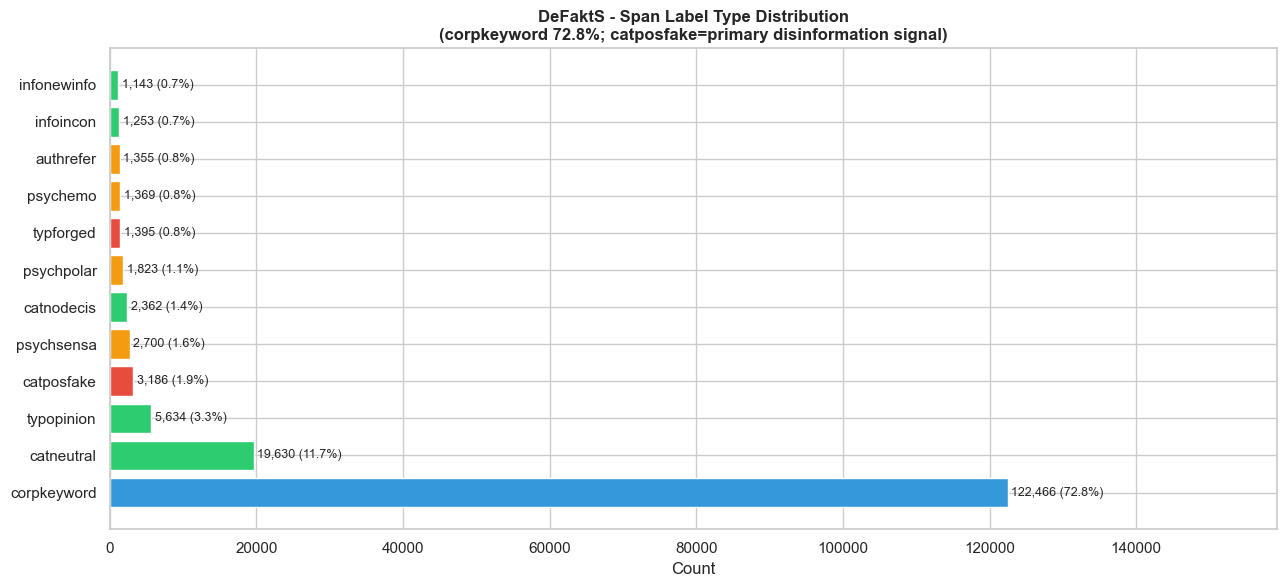

Fig 2 saved, defakts_span_types.png


In [4]:
all_labels = []
for spans in df['span_labels'].dropna():
    if isinstance(spans, list):
        for span in spans:
            if len(span) >= 3:
                all_labels.append(span[2])
label_counts = Counter(all_labels)
top_labels = label_counts.most_common(12)
labels, counts = zip(*top_labels)
colors = ['#e74c3c' if 'fake' in l or 'forged' in l or 'conspir' in l
          else '#f39c12' if 'psych' in l or 'auth' in l
          else '#3498db' if 'corp' in l
          else '#2ecc71' for l in labels]

fig, ax = plt.subplots(figsize=(13, 6))
bars = ax.barh(range(len(labels)), counts, color=colors, edgecolor='white')
for bar, val in zip(bars, counts):
    ax.text(bar.get_width()+500, bar.get_y()+bar.get_height()/2,
            f'{val:,} ({val/len(all_labels):.1%})', va='center', fontsize=9)
ax.set_yticks(range(len(labels))); ax.set_yticklabels(labels)
ax.set_title('DeFaktS - Span Label Type Distribution\n(corpkeyword 72.8%; catposfake=primary disinformation signal)', fontsize=12, fontweight='bold')
ax.set_xlabel('Count'); ax.set_xlim(0, max(counts)*1.3)
plt.tight_layout()
plt.savefig('../figures/eda/defakts_span_types.png', dpi=150, bbox_inches='tight')
plt.show(); print('Fig 2 saved, defakts_span_types.png')

## 3. Span Coverage Distribution

Mean 1.6 spans per record, max 62. 86.3% have at least one span annotation.

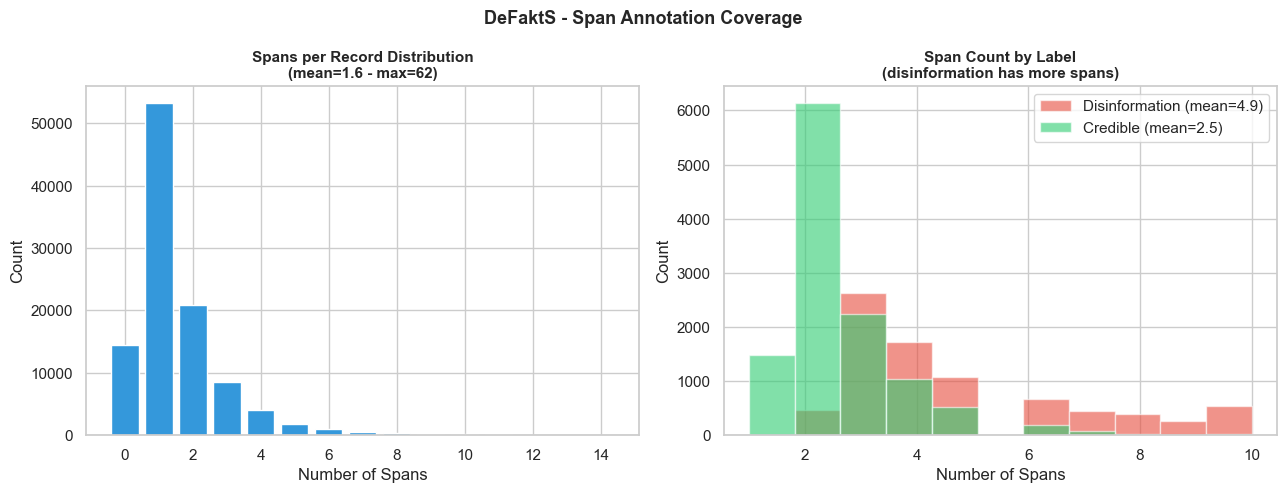

Fig 3 saved, defakts_span_coverage.png


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

span_dist = df['span_count'].value_counts().sort_index().head(15)
axes[0].bar(span_dist.index, span_dist.values, color='#3498db', edgecolor='white')
axes[0].set_title('Spans per Record Distribution\n(mean=1.6 - max=62)', fontsize=11, fontweight='bold')
axes[0].set_xlabel('Number of Spans'); axes[0].set_ylabel('Count')

# Span count by binary label
labeled = df[df['binary_label'].notna()]
for label, color, name in [(1,'#e74c3c','Disinformation'),(0,'#2ecc71','Credible')]:
    subset = labeled[labeled['binary_label']==label]
    axes[1].hist(subset['span_count'].clip(upper=10), bins=11, alpha=0.6,
                color=color, label=f'{name} (mean={subset["span_count"].mean():.1f})', edgecolor='white')
axes[1].set_title('Span Count by Label\n(disinformation has more spans)', fontsize=11, fontweight='bold')
axes[1].set_xlabel('Number of Spans'); axes[1].set_ylabel('Count'); axes[1].legend()

plt.suptitle('DeFaktS - Span Annotation Coverage', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../figures/eda/defakts_span_coverage.png', dpi=150, bbox_inches='tight')
plt.show(); print('Fig 3 saved, defakts_span_coverage.png')

## 4. Text Length Distribution

Mean=187 chars, median=192, near Twitter limit. Disinformation (193) slightly longer than credible (184).

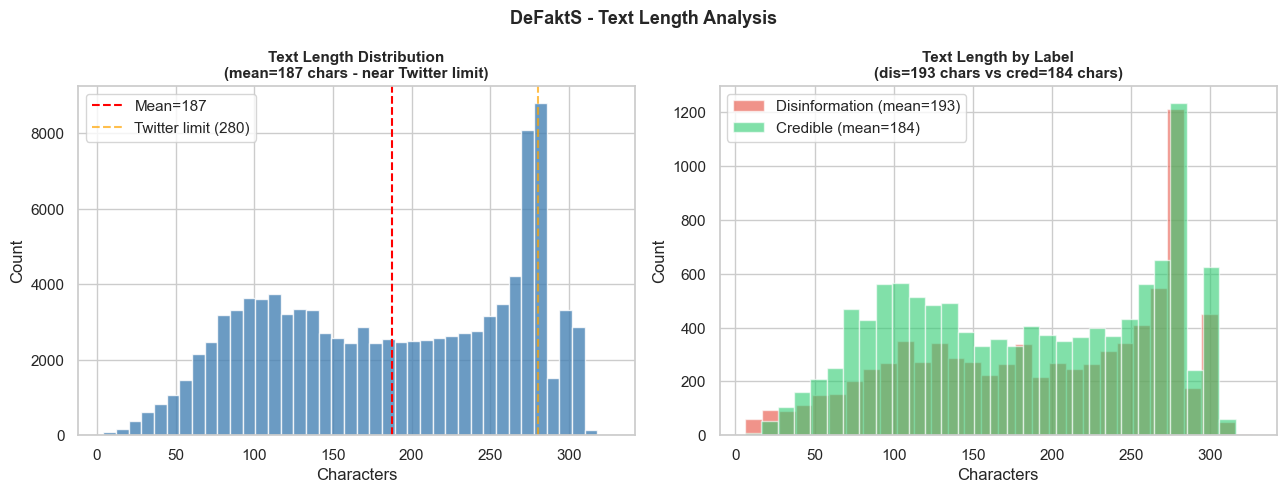

Fig 4 saved, defakts_text_length.png


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].hist(df['text_len'], bins=40, color='steelblue', edgecolor='white', alpha=0.8)
axes[0].axvline(df['text_len'].mean(), color='red', linestyle='--', label=f'Mean={df["text_len"].mean():.0f}')
axes[0].axvline(280, color='orange', linestyle='--', alpha=0.7, label='Twitter limit (280)')
axes[0].set_title('Text Length Distribution\n(mean=187 chars - near Twitter limit)', fontsize=11, fontweight='bold')
axes[0].set_xlabel('Characters'); axes[0].set_ylabel('Count'); axes[0].legend()

labeled = df[df['binary_label'].notna()]
for label, color, name in [(1,'#e74c3c','Disinformation'),(0,'#2ecc71','Credible')]:
    subset = labeled[labeled['binary_label']==label]
    axes[1].hist(subset['text_len'], bins=30, alpha=0.6, color=color,
                label=f'{name} (mean={subset["text_len"].mean():.0f})', edgecolor='white')
axes[1].set_title('Text Length by Label\n(dis=193 chars vs cred=184 chars)', fontsize=11, fontweight='bold')
axes[1].set_xlabel('Characters'); axes[1].set_ylabel('Count'); axes[1].legend()

plt.suptitle('DeFaktS - Text Length Analysis', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../figures/eda/defakts_text_length.png', dpi=150, bbox_inches='tight')
plt.show(); print('Fig 4 saved, defakts_text_length.png')

## 5. Engagement Metrics, Disinformation Gets More Engagement

Disinformation: LikeCount=29.3, RT=6.1. Credible: LikeCount=21.7, RT=4.8.
Median=0-1 for all, viral outliers drive means.

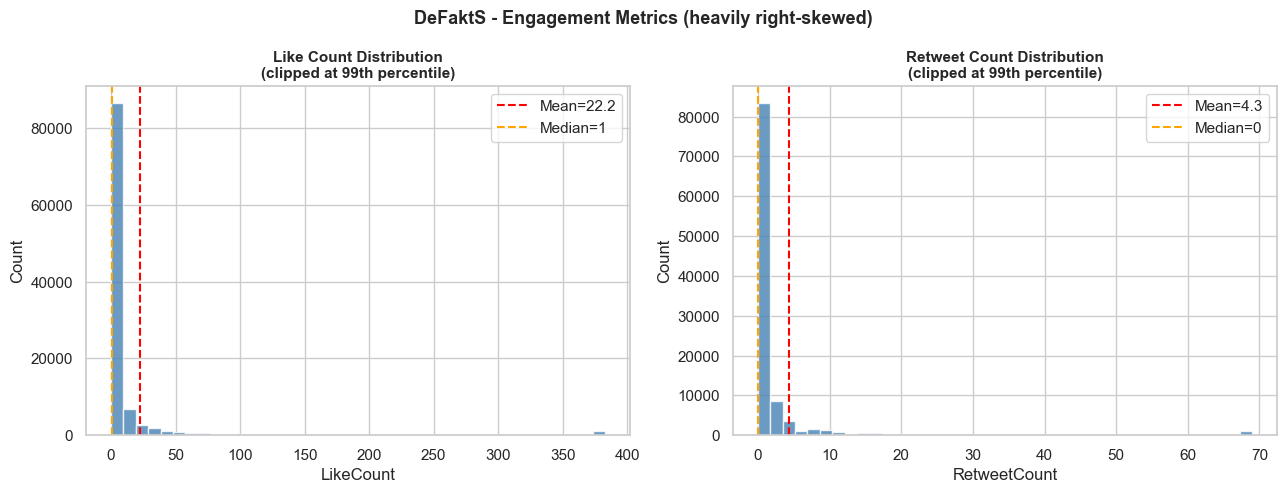

Fig 5 saved, defakts_engagement.png


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Overall engagement distribution (clipped)
for col, ax, title in [('LikeCount', axes[0], 'Like Count'), ('RetweetCount', axes[1], 'Retweet Count')]:
    clipped = df[col].clip(upper=df[col].quantile(0.99))
    ax.hist(clipped, bins=40, color='steelblue', edgecolor='white', alpha=0.8)
    ax.axvline(df[col].mean(), color='red', linestyle='--', label=f'Mean={df[col].mean():.1f}')
    ax.axvline(df[col].median(), color='orange', linestyle='--', label=f'Median={df[col].median():.0f}')
    ax.set_title(f'{title} Distribution\n(clipped at 99th percentile)', fontsize=11, fontweight='bold')
    ax.set_xlabel(col); ax.set_ylabel('Count'); ax.legend()

plt.suptitle('DeFaktS - Engagement Metrics (heavily right-skewed)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../figures/eda/defakts_engagement.png', dpi=150, bbox_inches='tight')
plt.show(); print('Fig 5 saved, defakts_engagement.png')

## 6. Engagement by Label, Disinformation More Viral

Disinformation LikeCount=29.3 vs Credible=21.7 (+35%).
Disinformation RT=6.1 vs Credible=4.8 (+27%). Virality signal for disinformation.

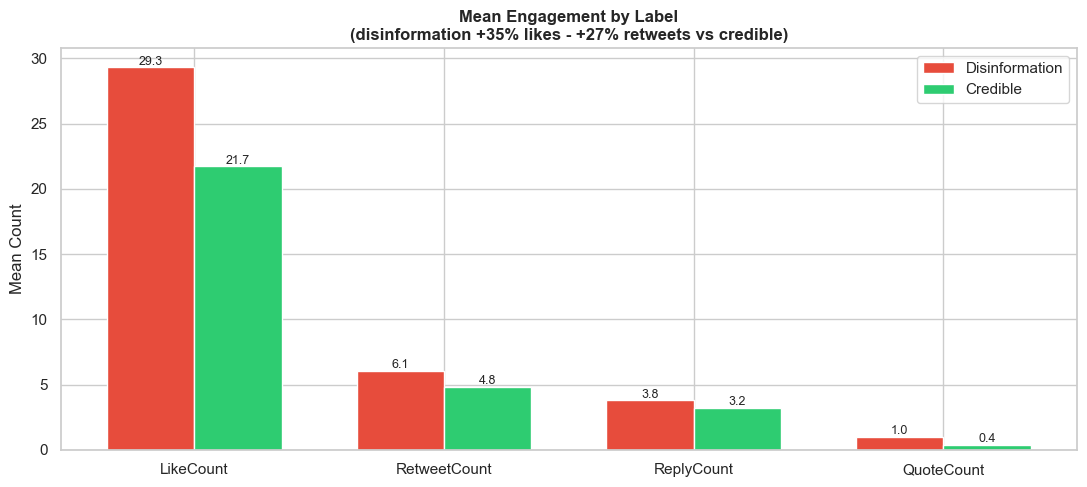

Fig 6 saved, defakts_engagement_by_label.png


In [8]:
labeled = df[df['binary_label'].notna()].copy()
metrics = ['LikeCount','RetweetCount','ReplyCount','QuoteCount']
dis_means = [labeled[labeled['binary_label']==1][m].mean() for m in metrics]
cred_means = [labeled[labeled['binary_label']==0][m].mean() for m in metrics]
x = np.arange(len(metrics)); width = 0.35

fig, ax = plt.subplots(figsize=(11, 5))
bars1 = ax.bar(x-width/2, dis_means, width, color='#e74c3c', label='Disinformation', edgecolor='white')
bars2 = ax.bar(x+width/2, cred_means, width, color='#2ecc71', label='Credible', edgecolor='white')
for bar, val in zip(bars1, dis_means):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.2, f'{val:.1f}', ha='center', fontsize=9)
for bar, val in zip(bars2, cred_means):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.2, f'{val:.1f}', ha='center', fontsize=9)
ax.set_xticks(x); ax.set_xticklabels(metrics)
ax.set_title('Mean Engagement by Label\n(disinformation +35% likes - +27% retweets vs credible)', fontsize=12, fontweight='bold')
ax.set_ylabel('Mean Count'); ax.legend()
plt.tight_layout()
plt.savefig('../figures/eda/defakts_engagement_by_label.png', dpi=150, bbox_inches='tight')
plt.show(); print('Fig 6 saved, defakts_engagement_by_label.png')

## 6b. Engagement Statistical Tests, LikeCount + ReplyCount Significant

Mann-Whitney U: LikeCount p=0.0007, ReplyCount p=0.0001, SIGNIFICANT.
RetweetCount p=0.5623, not significant. Disinformation virality statistically confirmed.

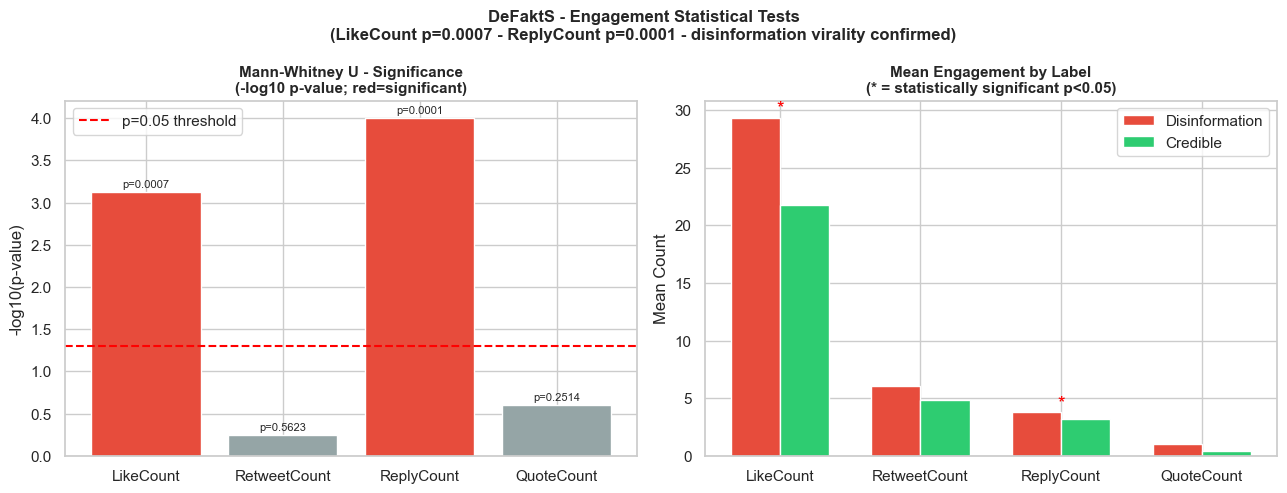

Fig 6b saved, defakts_engagement_stats.png


In [9]:
from scipy import stats
labeled_mw = df[df['binary_label'].notna()]
dis_mw = labeled_mw[labeled_mw['binary_label']==1]
cred_mw = labeled_mw[labeled_mw['binary_label']==0]
metrics = ['LikeCount','RetweetCount','ReplyCount','QuoteCount']
pvals = []
stats_vals = []
for col in metrics:
    stat, pval = stats.mannwhitneyu(dis_mw[col], cred_mw[col], alternative='two-sided')
    pvals.append(pval)
    stats_vals.append(stat)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
colors_p = ['#e74c3c' if p < 0.05 else '#95a5a6' for p in pvals]
bars = axes[0].bar(metrics, [-np.log10(p) for p in pvals], color=colors_p, edgecolor='white')
axes[0].axhline(-np.log10(0.05), color='red', linestyle='--', label='p=0.05 threshold')
for bar, p in zip(bars, pvals):
    axes[0].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.05,
                f'p={p:.4f}', ha='center', fontsize=8)
axes[0].set_title('Mann-Whitney U - Significance\n(-log10 p-value; red=significant)', fontsize=11, fontweight='bold')
axes[0].set_ylabel('-log10(p-value)'); axes[0].legend()

dis_means = [dis_mw[m].mean() for m in metrics]
cred_means = [cred_mw[m].mean() for m in metrics]
x = np.arange(len(metrics)); width = 0.35
axes[1].bar(x-width/2, dis_means, width, color='#e74c3c', label='Disinformation', edgecolor='white')
axes[1].bar(x+width/2, cred_means, width, color='#2ecc71', label='Credible', edgecolor='white')
for i, (p, dm, cm) in enumerate(zip(pvals, dis_means, cred_means)):
    if p < 0.05:
        axes[1].text(i, max(dm,cm)+0.3, '*', ha='center', fontsize=14, color='red')
axes[1].set_xticks(x); axes[1].set_xticklabels(metrics)
axes[1].set_title('Mean Engagement by Label\n(* = statistically significant p<0.05)', fontsize=11, fontweight='bold')
axes[1].set_ylabel('Mean Count'); axes[1].legend()

plt.suptitle('DeFaktS - Engagement Statistical Tests\n(LikeCount p=0.0007 - ReplyCount p=0.0001 - disinformation virality confirmed)', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('../figures/eda/defakts_engagement_stats.png', dpi=150, bbox_inches='tight')
plt.show()
print('Fig 6b saved, defakts_engagement_stats.png')

## 7. Temporal Distribution, 97.2% Post-2019

Massive surge in 2022-2023 (66,181 in 2023 alone). Dataset heavily recent-biased.

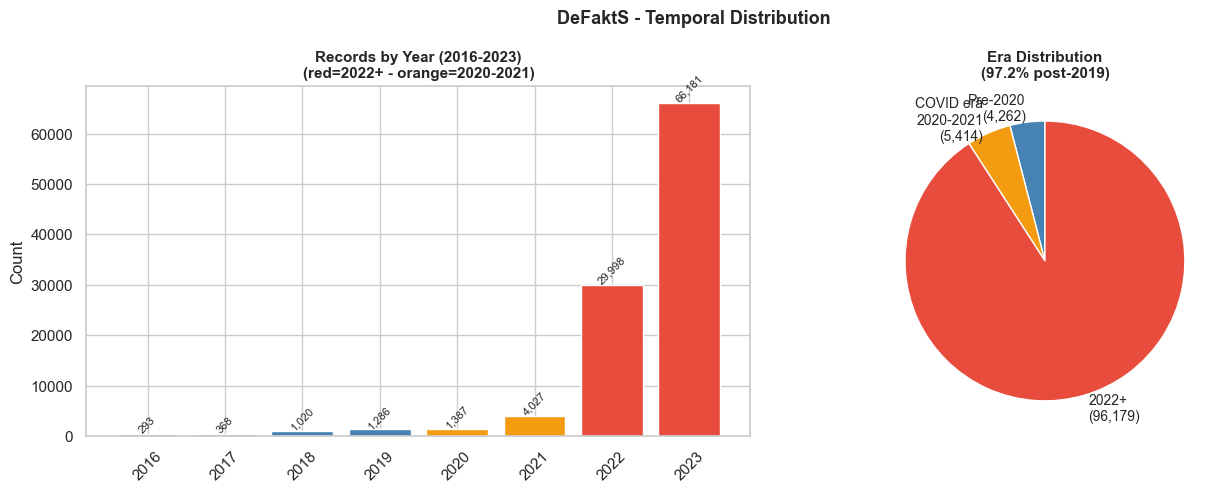

Fig 7 saved, defakts_temporal.png


In [10]:
year_counts = df['year'].value_counts().sort_index()
years_plot = year_counts[year_counts.index >= 2016]
colors_year = ['#e74c3c' if y >= 2022 else '#f39c12' if y >= 2020 else 'steelblue' for y in years_plot.index]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
bars = axes[0].bar(years_plot.index.astype(str), years_plot.values, color=colors_year, edgecolor='white')
for bar, val in zip(bars, years_plot.values):
    axes[0].text(bar.get_x()+bar.get_width()/2, bar.get_height()+200,
                 f'{val:,}', ha='center', fontsize=8, rotation=45)
axes[0].set_title('Records by Year (2016-2023)\n(red=2022+ - orange=2020-2021)', fontsize=11, fontweight='bold')
axes[0].set_ylabel('Count'); axes[0].tick_params(axis='x', rotation=45)

pre = df[df['year']<2020]['year'].notna().sum()
covid = df[(df['year']>=2020)&(df['year']<2022)]['year'].notna().sum()
recent = df[df['year']>=2022]['year'].notna().sum()
axes[1].pie([pre, covid, recent],
            labels=[f'Pre-2020\n({pre:,})', f'COVID era\n2020-2021\n({covid:,})', f'2022+\n({recent:,})'],
            colors=['steelblue','#f39c12','#e74c3c'], startangle=90, textprops={'fontsize':10})
axes[1].set_title('Era Distribution\n(97.2% post-2019)', fontsize=11, fontweight='bold')

plt.suptitle('DeFaktS - Temporal Distribution', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../figures/eda/defakts_temporal.png', dpi=150, bbox_inches='tight')
plt.show(); print('Fig 7 saved, defakts_temporal.png')

## 8. Hashtag Analysis, No Discriminating Signal

Disinformation 52.4% vs Credible 51.6%, nearly identical. Hashtags not a useful disinformation signal.

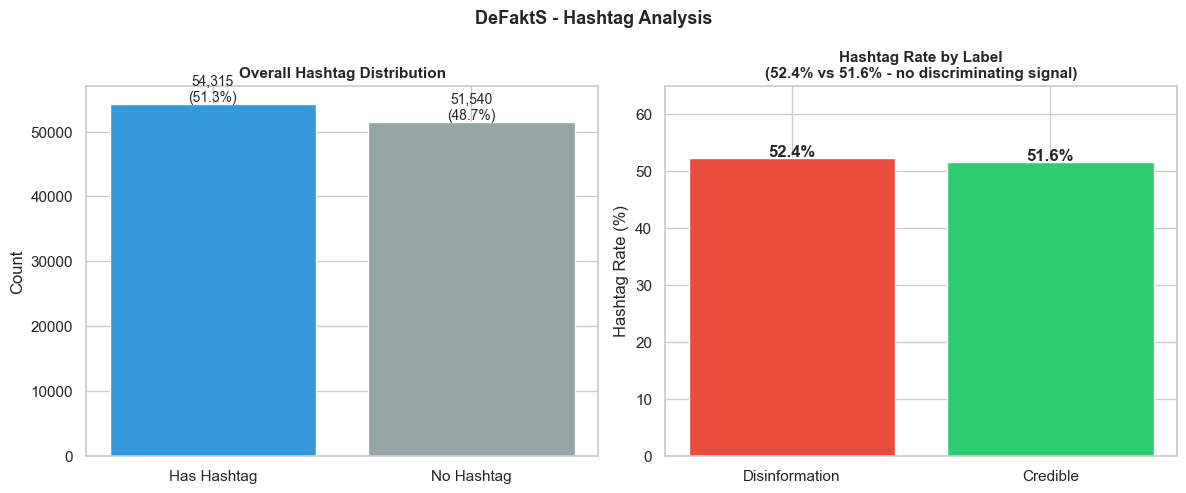

Fig 8 saved, defakts_hashtags.png


In [11]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

has_hashtag = df['Hashtags'].notna()
axes[0].bar(['Has Hashtag', 'No Hashtag'], [has_hashtag.sum(), (~has_hashtag).sum()],
           color=['#3498db','#95a5a6'], edgecolor='white')
for i, val in enumerate([has_hashtag.sum(), (~has_hashtag).sum()]):
    axes[0].text(i, val+300, f'{val:,}\n({val/len(df):.1%})', ha='center', fontsize=10)
axes[0].set_title('Overall Hashtag Distribution', fontsize=11, fontweight='bold')
axes[0].set_ylabel('Count')

labeled = df[df['binary_label'].notna()]
dis_ht = labeled[labeled['binary_label']==1]['Hashtags'].notna().mean()*100
cred_ht = labeled[labeled['binary_label']==0]['Hashtags'].notna().mean()*100
axes[1].bar(['Disinformation', 'Credible'], [dis_ht, cred_ht],
           color=['#e74c3c','#2ecc71'], edgecolor='white')
for i, val in enumerate([dis_ht, cred_ht]):
    axes[1].text(i, val+0.3, f'{val:.1f}%', ha='center', fontsize=12, fontweight='bold')
axes[1].set_title('Hashtag Rate by Label\n(52.4% vs 51.6% - no discriminating signal)', fontsize=11, fontweight='bold')
axes[1].set_ylabel('Hashtag Rate (%)'); axes[1].set_ylim(0, 65)

plt.suptitle('DeFaktS - Hashtag Analysis', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../figures/eda/defakts_hashtags.png', dpi=150, bbox_inches='tight')
plt.show(); print('Fig 8 saved, defakts_hashtags.png')

## 9. Missing Values

binary_label: 81.1% missing, primary gap. span_labels: 0% missing. All other fields complete.

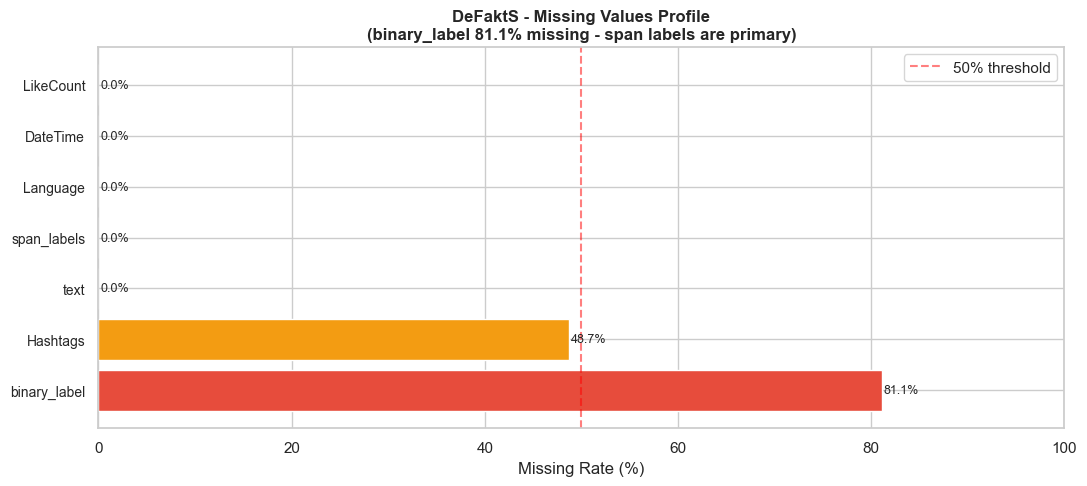

Fig 9 saved, defakts_missing_values.png


In [12]:
key_cols = ['text','binary_label','span_labels','Language','DateTime','LikeCount','Hashtags']
null_rates = [(col, df[col].isnull().mean()*100) for col in key_cols]
null_rates.sort(key=lambda x: x[1], reverse=True)
cols, pcts = zip(*null_rates)
colors_miss = ['#e74c3c' if p > 50 else '#f39c12' if p > 20 else '#2ecc71' for p in pcts]

fig, ax = plt.subplots(figsize=(11, 5))
ax.barh(range(len(cols)), pcts, color=colors_miss, edgecolor='white')
ax.set_yticks(range(len(cols))); ax.set_yticklabels(cols, fontsize=10)
for i, (col, pct) in enumerate(zip(cols, pcts)):
    ax.text(pct+0.2, i, f'{pct:.1f}%', va='center', fontsize=9)
ax.axvline(50, color='red', linestyle='--', alpha=0.5, label='50% threshold')
ax.set_title('DeFaktS - Missing Values Profile\n(binary_label 81.1% missing - span labels are primary)', fontsize=12, fontweight='bold')
ax.set_xlabel('Missing Rate (%)'); ax.legend(); ax.set_xlim(0, 100)
plt.tight_layout()
plt.savefig('../figures/eda/defakts_missing_values.png', dpi=150, bbox_inches='tight')
plt.show(); print('Fig 9 saved, defakts_missing_values.png')

## 9b. Span Types by Label, typopinion Key Disinformation Signal

Disinformation: typopinion=14.0%, catposfake=7.9%, psychsensa=6.7%.
Credible: catneutral=51.0% dominates. typopinion 2,816x more common in disinformation.

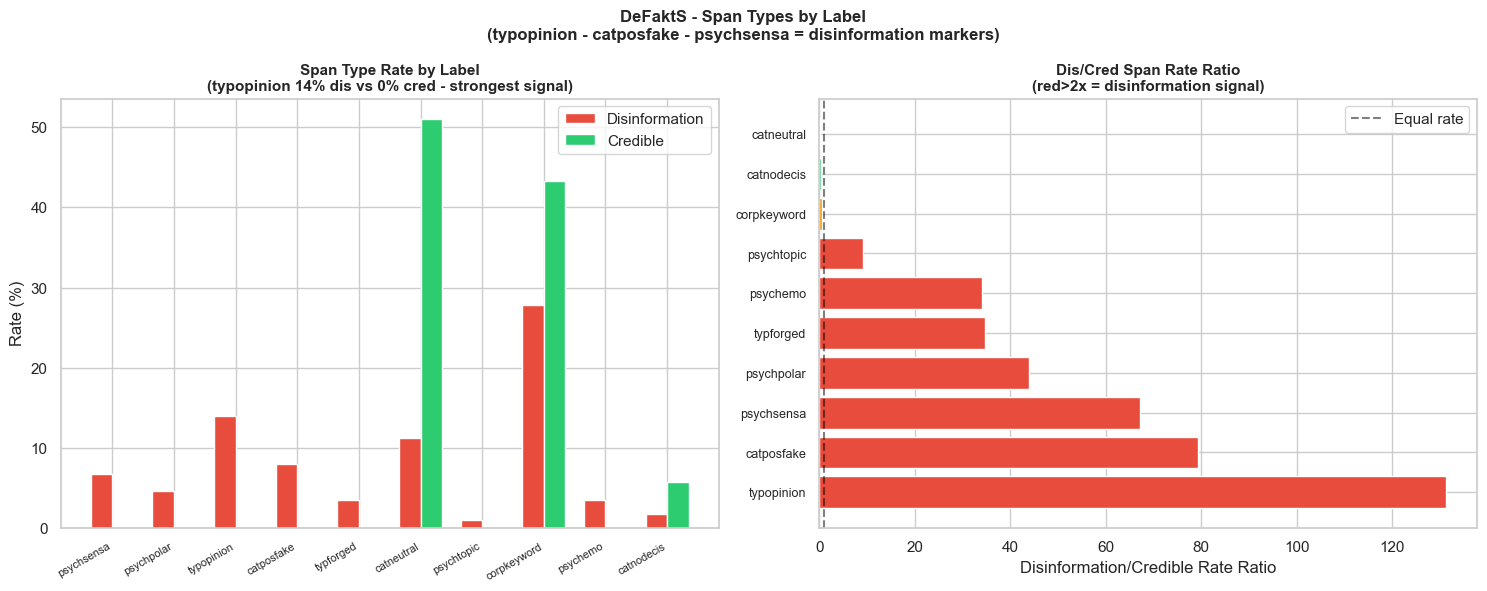

Fig 9b saved, defakts_span_by_label.png


In [13]:
from collections import defaultdict, Counter
label_span_counts = defaultdict(Counter)
for _, row in df.iterrows():
    if pd.notna(row['binary_label']) and isinstance(row['span_labels'], list):
        for span in row['span_labels']:
            if len(span) >= 3:
                label_span_counts[int(row['binary_label'])][span[2]] += 1

all_types = set()
for label in [0,1]:
    all_types.update([k for k,v in label_span_counts[label].most_common(8)])
all_types = list(all_types)

dis_total = sum(label_span_counts[1].values())
cred_total = sum(label_span_counts[0].values())
dis_rates = [label_span_counts[1].get(t,0)/dis_total*100 for t in all_types]
cred_rates = [label_span_counts[0].get(t,0)/cred_total*100 for t in all_types]

x = np.arange(len(all_types)); width = 0.35
fig, axes = plt.subplots(1, 2, figsize=(15, 6))
bars1 = axes[0].bar(x-width/2, dis_rates, width, color='#e74c3c', label='Disinformation', edgecolor='white')
bars2 = axes[0].bar(x+width/2, cred_rates, width, color='#2ecc71', label='Credible', edgecolor='white')
axes[0].set_xticks(x); axes[0].set_xticklabels(all_types, rotation=30, ha='right', fontsize=8)
axes[0].set_title('Span Type Rate by Label\n(typopinion 14% dis vs 0% cred - strongest signal)', fontsize=11, fontweight='bold')
axes[0].set_ylabel('Rate (%)'); axes[0].legend()

# Top discriminating spans, ratio
dis_only = {t: label_span_counts[1].get(t,0)/dis_total for t in all_types}
cred_only = {t: label_span_counts[0].get(t,0)/cred_total for t in all_types}
ratios = {t: dis_only[t]/(cred_only[t]+0.001) for t in all_types}
ratio_sorted = sorted(ratios.items(), key=lambda x: x[1], reverse=True)
ratio_labels, ratio_vals = zip(*ratio_sorted)
colors_ratio = ['#e74c3c' if v > 2 else '#f39c12' if v > 0.5 else '#2ecc71' for v in ratio_vals]
axes[1].barh(range(len(ratio_labels)), ratio_vals, color=colors_ratio, edgecolor='white')
axes[1].set_yticks(range(len(ratio_labels))); axes[1].set_yticklabels(ratio_labels, fontsize=9)
axes[1].axvline(1, color='black', linestyle='--', alpha=0.5, label='Equal rate')
axes[1].set_title('Dis/Cred Span Rate Ratio\n(red>2x = disinformation signal)', fontsize=11, fontweight='bold')
axes[1].set_xlabel('Disinformation/Credible Rate Ratio'); axes[1].legend()

plt.suptitle('DeFaktS - Span Types by Label\n(typopinion - catposfake - psychsensa = disinformation markers)', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('../figures/eda/defakts_span_by_label.png', dpi=150, bbox_inches='tight')
plt.show()
print('Fig 9b saved, defakts_span_by_label.png')

## 10. Key Observations

**Total: 105,855 German tweets**, 100% German, 15-year span (2008-2023)
**Binary label: 81.1% missing**, span labels are primary annotation (86.3% coverage)
**catposfake=3,186 spans**, primary disinformation signal; corpkeyword dominates (72.8%)
**Disinformation more viral:** LikeCount +35%, Retweet +27% vs credible
**97.2% post-2019**, massive 2022-2023 surge (66,181 in 2023 alone)
**Hashtags: no signal**, dis=52.4% vs cred=51.6%, nearly identical
**Text length near Twitter limit**, mean=187 chars, median=192
**HyDMIS role:** German fine-grained span-level disinformation detection benchmark